On DAP, we can't install ipykernel in `.venv`. Thus, we need to apply a different strategy.

* do `unzip -o graph-ensemble.zip` 
If not working, remove `mc rm -rf graph-ensemble` and, then, `unzip graph-ensembles.zip`;
* `deactivate` (the `virtual-env`) such that the standard jupter kernel is selected;
* install via `pip install --editable . --config-settings editable_mode=compat`
* create a cell down here and do `import graph_ensembles` to check for the installation;

Usefull Commands:
* For this project, ```vars``` and ```plots``` are saved in `./outputs`;
* Delete folders on dap: ```mc rm --force --purge folder```
* To save new plots, delete previous ones with
```mc rm --force --purge dap/corealgos/rmilocco/outputs/datasets/ING-Directed```

On local:
* Linux: Zip outside the ``graph-ensembles`` folder: 
<br>```zip -rX graph-ensembles.zip graph-ensembles -x "graph-ensembles/src/graph_ensembles.egg-info/*" ".*" "*/.*" "*/__pycache__/*" "*/sythetic_network/*"```

Run the right install cmd from [pytorch](https://pytorch.org/), based on your architecture

Claim: by reconstructing the unobserved, we may close the gap between the total Page-Rank and Page-Rank only inside the ING-clients

1) Split the nodes into ING (`vI`) and `ROW` (`vR`);

2) Find ``vI`` and ``eI`` as the edges only between. We will cal `intra` (`eI`) edges, `bet` (ING-ROW), `row` (non ING interacting clients); 

4) Calculate the Page-Rank of only the `intra` nodes and compare it with the full graph PR.
Now, we expect that the 2 PR are different. So, help this bias by reconstructing the missing part. Ref [LateX](https://asajadi.github.io/fast-pagerank/) based on [MathWorks](https://www.mathworks.com/content/dam/mathworks/mathworks-dot-com/moler/exm/chapters/pagerank.pdf);

5) Calculate the strengths taking into account also the ING-ROW fluxes, while discarding the self-payments;
6) Freeze the `eI` and fit $\delta$ parameter as 
    * $L_I \stackrel{!}{=} \langle L_I \rangle(\delta_I) := \sum_{i \in I, j \in I} p_{ij}(\delta_I)$;

    * $L^{no-I}_U = L_I + L_{bet} \stackrel{!}{=} L_I + \sum_{i \in I, r \in R} (p_{ir}(\delta_{U}) + p_{ri}(\delta_{U})) $;

    * $L_U = L_I + L_{bet} \stackrel{!}{=} \sum_{(i,j) \in \left\{(I,I),(I,R),(R,I) \right\} } p_{ij}(\delta_{U}) $;

7) Page-Rank (or Influence Vector);

In [1]:
# auto-reload the packages at every run
%load_ext autoreload
%autoreload 2

#display all the results not only the last one
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import os
try:
    corpkey = True if os.environ['DSBOX_USERNAME'] else None
    # %pip install matplotlib pandas scipy tqdm torch torchvision
except:
    corpkey = None

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch as tc
import graph_ensembles as ge
from graph_ensembles import sparse as sp
import graph_ensembles.utils as utils
import graph_ensembles.dependencies as dep
from graph_ensembles.plots import plotting_functions as plot

plot.plot_local_fonts(corpkey)
utils._set_mpl_params(fontsize=20)
utils.check_cpu_gpu_with_torch()

dataset_name = "ING" #"recNET"
dataset_direction = "Directed"
id_code, cg_method, year = "grid_id", "random", 2022


-Logical CPUs: 22
-GPUs in use:
-Number of GPUs: 1
  GPU 0: NVIDIA GeForce RTX 4060 Laptop GPU
    - Compute Capability: 89
    - Total Memory: 8187 MB
    - Multiprocessors: 24
-Current CUDA device: 0
-CUDA version: 12.8
-total_cores: 3072


In [2]:
# note that inside the kwargs there is a copy of the pdtrans
max_num_entries = None if corpkey else 1e3 #30e6
pdtrans, kwargs, total_levels = \
    ge.dataset_loader(dataset_name, dataset_direction = dataset_direction,
                    corpkey = corpkey, id_code = id_code, cg_method = cg_method,
                    year = year, max_num_entries = max_num_entries) #63332573


Reading from local source


Define all the vertex and edges

In [3]:
e = pdtrans.loc[:, [f'payer_{id_code}', f'beneficiary_{id_code}']]
unique_nodes_from = lambda df: pd.DataFrame(data = np.unique(df.to_numpy().ravel('K')), columns = ["id"])
v = unique_nodes_from(e)
e = pdtrans.iloc[:, ::2] # payer, beneficiary, amount_euro
e.columns = ["src", "dst", "amount"] 

e.head()
print(f'-v.shape: {v.shape}',)

,src,dst,amount
0,147,216011,3280.890760
1,161,372779,127.738379
2,494,59516,1301.115251
3,1263,1351,615.526070
4,1488,6569,2892.115558


-v.shape: (1823, 1)


Create Full Graph

In [4]:
ivec_name = "page_rank"
kwargs_graph = {'name' : 'ING', 'level' : 0, 'corpkey' : corpkey, "ivec_name" : ivec_name}
g = sp.graphs.DiGraph(v, e, **kwargs_graph)
# g.load_or_create_degrees()

del pdtrans

In [5]:
g._kwargs_pr = {"p" : 0.85, "max_iter" : 200, "tol" : 1e-06}
g.ivec = g.pagerank_power(**g._kwargs_pr)
g.save_vars()

Create a split of ``v`` into `vI`

Fit the `delta_intra`, for a splitting

In [6]:
from os.path import dirname as up
from tqdm import trange

vsplits, intra_sizes = [0], [0.2]
x0 = [1.8996372e-17]

# sample arguments
num_graph_samples_per_vsplit = 11
chunk_row_size = 1000
ivec_name = "page_rank"
title_ivec = ivec_name.replace('_', '')
rtol = 1e-8

for intra_size in intra_sizes:
    
    for vsplit in vsplits:
       
        # vsplit nodes, edges in interal (vsplit = seed)
        vI, eI = g.vsplit_intra_row(v, e, intra_size=intra_size, vsplit=vsplit)

        # mask unsampled_vI for fast sampling, frozen edges (integer eI), 
        unsampled_vI, frozen_edges, gI = g._set_frozen_edges_gI(intra_size, vsplit, vI, eI, kwargs_graph)
        
        # add kwargs for the model
        kwargs_model = kwargs_graph.copy()
        kwargs_model.update({"name" : "Invariant"})
        model = sp.ScaleInvariantModel(gI, **kwargs_model)
            
        # load or fit the param
        model.load_or_fit(x0 = x0[0], maxiter = 30, verbose = 2)

        # update the model to predict full net
        model.num_vertices = g.num_vertices
        model.prop_out = g.out_strength()
        model.prop_in = g.in_strength()
        
        num_sampled_graphs, ivec, ivec_std = model.set_ensemble_variables(ivec_name, num_graph_samples_per_vsplit)

        print(f'\n-For vsplitting vsplit {vsplit}: {num_sampled_graphs} graphs already sampled, {np.clip(num_graph_samples_per_vsplit - num_sampled_graphs, 0, None)} remaining')

        # send variables (model.params, ...) to cuda:0
        unsampled_vI = model.send_variables_to_gpu(unsampled_vI)

        # track max of ens std for early stopping
        max_ivec_std = []

        # set the page rank on g, gI
        utils.set_ivec_on_I(g, gI)

        # Note: the seed = vsplit only works for solo-agent. The graph-sampling is parallelized, so it would be random even if vsplit specified.
        # That's why .sample() has graph_idx as argument
        # set graph_idx = 0, since if all the graphs are already sampled in the next calculations it will have a number different to None
        for graph_idx in trange(num_sampled_graphs, num_graph_samples_per_vsplit, 
                        desc=f"-Total progress {int(np.round(vsplit/len(vsplits) * 100))}%, Inner Graph Sampling", position = 0, leave= True):
            
            # only at 1st iteration
            if graph_idx == num_sampled_graphs:
                prev_ivec, prev_ivec_std = ivec.copy(), ivec_std.copy()

            # sample
            gs = model.sample(ref_g = g, unsampled_vI = unsampled_vI, frozen_edges = frozen_edges, 
                            graph_idx = graph_idx, chunk_row_size = chunk_row_size)

            model.ivec, model.ivec_std = model.recursive_mean_std(graph_idx, prev_ivec, prev_ivec_std, gs.ivec)
            max_ivec_std.append(np.max(model.ivec_std))

            # create 10 snapshot of the sampling vars and plots
            num_sampled_graphs = graph_idx + 1
            step = num_graph_samples_per_vsplit // 10
            if num_sampled_graphs % step == 0 and num_sampled_graphs > 1:
                
                # save the mean and std as [[mean],[std]]
                fname = model.ens_ivec_base_dir + f"/num_samples_{num_sampled_graphs}.csv"
                np.savetxt(fname, X = np.vstack((ivec, ivec_std)))

                # generate the plot of page-ranks
                num_bins = int(np.sqrt(model.num_vertices))
                utils.set_model_ivec_on_I(model, g)
                plot.ivec_on_internal_nodes(model, g, gI, num_bins, num_sampled_graphs)
                plot.ivec_on_internal_nodes_vs_rank(model, g, gI, num_sampled_graphs)
                plot.topN_overlap_rel_err(g, gI, model, num_sampled_graphs, N = 20)
                plot.norm_diffs_per_iteration(model.plots_dir, max_ivec_std)
                # plot.delete_files_with_pattern(model.plots_dir, num_sampled_graphs - 2 * step,)
            
            # if the max variance is low, stop sampling
            if np.max(model.ivec_std) < rtol and graph_idx > 0:
                print(f'-Breaking since max of ens std {np.round(np.max(ivec_std), 5)} < {rtol}',)
                break
            
            # redefine prev ivec and std
            prev_ivec = model.ivec.copy()
            prev_ivec_std = model.ivec_std.copy()

-Fit the parameter with num_edges_intra
x0 = [1.8996372e-17]
|f(x0)| = 50.99999866221138
    Iteration 1
    fun = -31.64014250804731
    fun_prime = 19727472325.259586
    dx = 7.241914849238281e-10
    x = [7.24191504e-10]
    |f(x)| = 31.64014250804731
    diff = [38122620.72588535]
 
    Iteration 2
    fun = -7.999434404023454
    fun_prime = 11679906985.57276
    dx = 1.6038619639848346e-09
    x = [2.32805347e-09]
    |f(x)| = 7.999434404023454
    diff = [2.21469315]
 
    Iteration 3
    fun = -0.5034646306702015
    fun_prime = 10295751205.59837
    dx = 6.84888536689933e-10
    x = [3.012942e-09]
    |f(x)| = 0.5034646306702015
    diff = [0.29418935]
 
    Iteration 4
    fun = -0.0019923942143265094
    fun_prime = 10214580993.333008
    dx = 4.890023278694224e-11
    x = [3.06184224e-09]
    |f(x)| = 0.0019923942143265094
    diff = [0.01623006]
 
    Iteration 5
    fun = -3.1206994322019455e-08
    fun_prime = 10214261015.037148
    dx = 1.9505393472595034e-13
    x = [

-Total progress 0%, Inner Graph Sampling: 100%|██████████| 11/11 [01:11<00:00,  6.54s/it]


In [23]:
model.ivec_std

array([3.57956233e-05, 3.52721854e-05, 3.52721854e-05, ...,
       3.52721854e-05, 3.52721854e-05, 3.52721854e-05], shape=(1823,))

[None, None, Text(0.5, 0, 'Top N Firms'), Text(0, 0.5, 'Overlap (%)')]

[None,
 None,
 Text(0.5, 0, 'Top N Firms'),
 Text(0, 0.5, 'Total Relative Error (%)')]

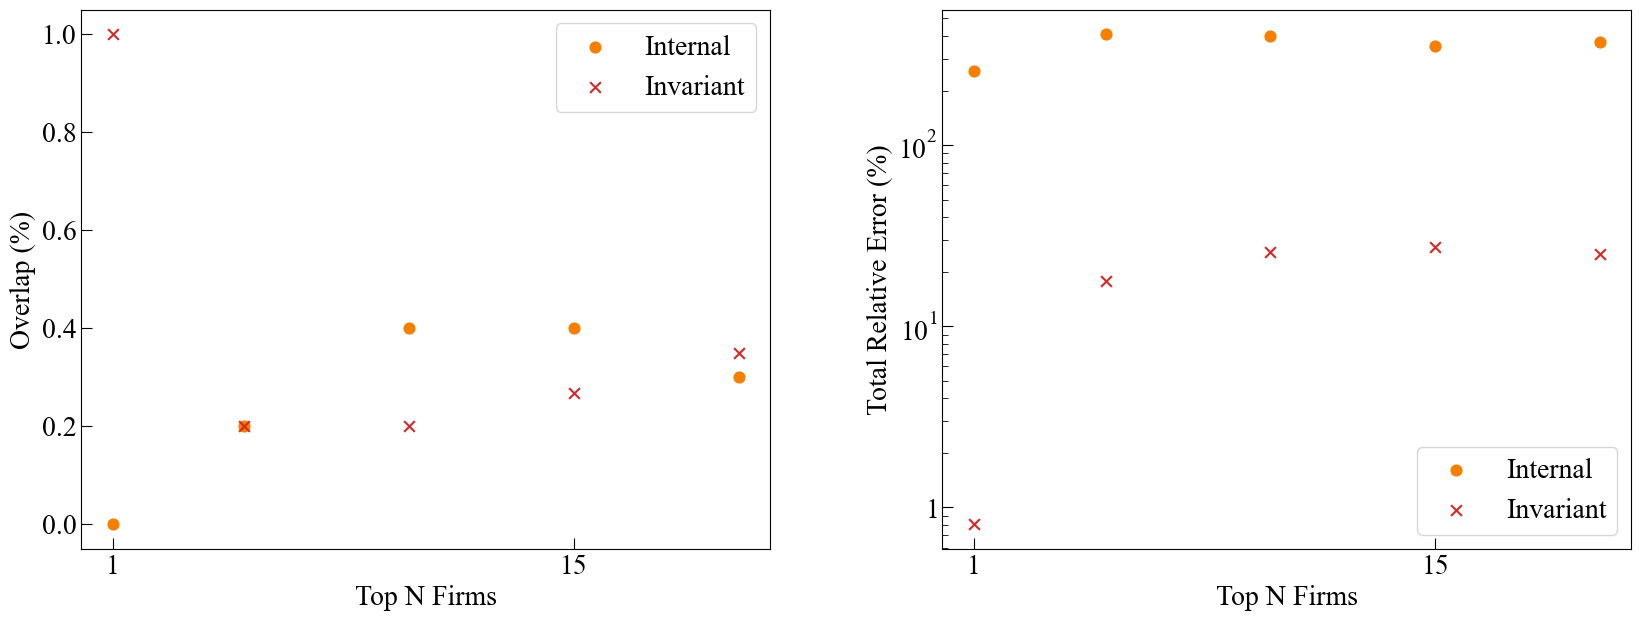

The `full` sampling procedure stays the same for all the fitting methods of delta (intra, united, full)

Plot the behavior of ens_avg

## Miscellanea

Fit `delta` with `L_Intra` num edges

In [ ]:
x0 = [1.8996372e-17]
model.load_or_fit(x0 = x0[0], maxiter = 30, verbose = 2)
# print(f'-utils.signed_rel_err(model._exp_num_edges, g._num_edges): {utils.signed_rel_err(model.expected_num_edges(), g._num_edges)}',)

-Load the parameter enforcing num_edges_full -> param: [6.30534189e-15]


### Compute observed Page-Ranks on the splitted networks

In [ ]:
# from os.path import dirname as up

# gI_dirfunc = lambda intra_size, vsplit: up(up(g.vars_dir)) + f"/intra_size{intra_size}/vsplit{vsplit}/level{g.level}"

# for intra_size in intra_sizes:
# 	for vsplit in range(num_vsplits):
        
# 		# vsplit nodes, edges in interal
# 		if not os.path.exists(gI_dirfunc(intra_size, vsplit)):
# 			vI, eI = g.vsplit_intra_row(v, e, intra_size=intra_size, vsplit=vsplit)

# 			# update the graph name
# 			kwargs_graph.update({'graph_kind': "intra", "intra_size" : intra_size, "vsplit" : vsplit})
# 			gI = sp.graphs.DiGraph(vI, eI, **kwargs_graph)

# 			# compute the page-rank only in the internal part
# 			gI.page_rank = gI.pagerank_power(**g._kwargs_pr)

# 			gI.save_vars()
            
# plot.pagerank_on_internal_nodes(g, gI_dirfunc, intra_size, num_vsplits,)

Filter them, retaining only Intra Nodes

In [ ]:
# g.in_strength()
# g.out_strength()
# gI._in_strength = g._in_strength[idx_IntraNode2Full]
# gI._out_strength = g._out_strength[idx_IntraNode2Full]

### Sampling with GPUs in Torch or CPUs with numba

In [ ]:
# Sampled torch GPU vs numba on CPU
# unsampled_vI = np.zeros(model.num_vertices, dtype=np.bool_)
# param, prop_out, prop_in, unsampled_vI = prop_to_torch(model, unsampled_vI)

# a = model.tc_block_parallel_sample(
#                 model.tc_p_ij,
#                 param,
#                 prop_out,
#                 prop_in,
#                 model.tc_prop_dyad,
#                 model.selfloops,
#                 unsampled_vI,
#                 chunk_row_size=200
#             )

# from graph_ensembles.sparse import DiGraphEnsemble
# unsampled_vI = np.zeros(model.num_vertices, dtype=np.bool_)
# a = DiGraphEnsemble.block_parallel_sample(
#                 model.p_ij,
#                 model.param,
#                 model.prop_out,
#                 model.prop_in,
#                 model.prop_dyad,
#                 model.selfloops,
#                 unsampled_vI,
#             )

### PyTorch row and col blocks (it is really slower than with only one for-loop)

Check if `unsampled_vI` entries are fixed

In [ ]:
import numpy as np
from itertools import product

# select the unsampled_vI
uns_id = np.where(unsampled_vI)[0]

# create a mapping from node to id
matidx_2_id = {k:v for k,v in enumerate(uns_id)}

# create a meshgrid
rows, cols = np.array(list(product(uns_id, repeat=2))).T
uns_N = len(uns_id)
print(f'-uns_N: {uns_N}',)

# filter the gs.adj for all the uns_id pairs
mat = gs.adj[rows, cols].reshape(uns_N, uns_N)

# find where mat is true
mat_rows, mat_cols = np.where(mat)

# create the DataFrame mapped into full-id nodes
frozen_edges_mat = pd.DataFrame({"_src" : mat_rows, "_dst" : mat_cols}).map(matidx_2_id.get)

# check the edges are the same
frozen_edges_mat.eq(frozen_edges).all()

-uns_N: 15


np.True_

Do Page-Rank for `gU`

In [ ]:
# find idx of edges containing v and filter edges
idx_at_least_one_ = lambda vI: e['src'].isin(vI['id']) | e['dst'].isin(vI['id'])

# containing vI, vR
idx_eU = idx_at_least_one_(vI)

# select the edge ING
eU = 3
# eU = edge_idx(idx_eU)

# reselect vU, since using v leads to inactive nodes not well-handled by the DiGraph
vU = unique_nodes_from(eU.iloc[:,:2])

In [ ]:
# kwargs_graph.update({'intra_size' : intra_size, 'vsplit' : vsplit, 'graph_kind' : "intra_inter",})
gU = sp.graphs.DiGraph(vU, eU, **kwargs_graph)
# g.load_or_create_degrees()

Compare the United PageRank vs Full PageRank over all the `vU` 

In [ ]:
pr_gU = pagerank_power(gU.adj, p=0.85, max_iter=100,
                   tol=1e-06, personalize=None, reverse=True)

In [ ]:
idx_IntraNode2United = list(map(lambda x: gU.id_dict.get(x), gI.id_dict))
pr_gU_on_Intra = pr_gU[idx_IntraNode2United]

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([pr_g_on_I.min(), pr_g_on_I.max()],
        [pr_g_on_I.min(), pr_g_on_I.max()],
        'r--')

ms, alpha = 30, 0.6
ax.scatter(pr_g_on_I, pr_gI, alpha=alpha, label = f"Intra PR", marker = 'o', c = dep.obs_color, s = ms)
ax.scatter(pr_g_on_I, pr_gU_on_Intra, alpha=alpha, label = f"United PR", marker = 'x', c = dep.ref_model_color, s = ms)
ax.set(
    xlabel='Full-PR on Intra',
    ylabel='Intra/United',
    title='PageRank: Intra/United VS Full',
    xscale='log',
    yscale='log'
)
leg = ax.legend()
for lh in leg.legend_handles:
    lh.set_alpha(1)
    lh.set_sizes([60])
ax.grid(False)

utils.save_fig(fig, full_path = g.plots_base_dir + "/PageRanks_on_Intra.pdf")
plt.close()

[Text(0.5, 0, 'Full-PR on Intra'),
 Text(0, 0.5, 'Intra/United'),
 Text(0.5, 1.0, 'PageRank: Intra/United VS Full'),
 None,
 None]